In [1]:
!pip install torch torchvision timm scikit-learn matplotlib tqdm opencv-python

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import timm
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [6]:
DATA_PATH = "../data/FF++"

print(os.listdir(DATA_PATH))

['fake', 'real']


In [7]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [9]:
import os
import cv2

DATA_PATH = "../data/FF++"
OUTPUT_PATH = "../data/FF_frames"

os.makedirs(OUTPUT_PATH, exist_ok=True)

for label in ["real","fake"]:

    video_folder = os.path.join(DATA_PATH,label)
    save_folder = os.path.join(OUTPUT_PATH,label)

    os.makedirs(save_folder, exist_ok=True)

    for video in os.listdir(video_folder):

        video_path = os.path.join(video_folder,video)

        cap = cv2.VideoCapture(video_path)

        frame_id = 0
        vid_name = video.split(".")[0]

        while True:

            ret, frame = cap.read()

            if not ret:
                break

            if frame_id % 10 == 0:

                filename = f"{vid_name}_{frame_id}.jpg"
                save_path = os.path.join(save_folder, filename)

                cv2.imwrite(save_path, frame)

            frame_id += 1

        cap.release()

print("Frame extraction complete")

Frame extraction complete


In [10]:
DATA_PATH = "../data/FF_frames"

dataset = ImageFolder(DATA_PATH, transform=transform)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['fake', 'real']
Total images: 31310


In [11]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

print(train_size, val_size)

25048 6262


In [12]:
cnn = timm.create_model("resnet50", pretrained=True)
cnn.fc = nn.Identity()
cnn = cnn.to(device)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [13]:
vit = timm.create_model("vit_base_patch16_224", pretrained=True)
vit.head = nn.Identity()
vit = vit.to(device)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [14]:
class HybridModel(nn.Module):

    def __init__(self, cnn, vit):
        super().__init__()
        self.cnn = cnn
        self.vit = vit
        
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 768, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512,2)
        )

    def forward(self,x):

        f1 = self.cnn(x)
        f2 = self.vit(x)

        fused = torch.cat((f1,f2),dim=1)

        out = self.classifier(fused)

        return out


model = HybridModel(cnn,vit).to(device)

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [19]:
from tqdm import tqdm
import time

def train_epoch():

    model.train()
    total_loss = 0

    progress = tqdm(train_loader, desc="Training", leave=False)

    for batch_idx, (images, labels) in enumerate(progress):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        progress.set_postfix(loss=loss.item())

    return total_loss / len(train_loader)

In [21]:
def validate():

    model.eval()

    preds = []
    gt = []

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc="Validating", leave=False):

            images = images.to(device)

            outputs = model(images)

            p = torch.argmax(outputs,1).cpu().numpy()

            preds.extend(p)
            gt.extend(labels.numpy())

    acc = accuracy_score(gt,preds)

    return acc

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.5877128].


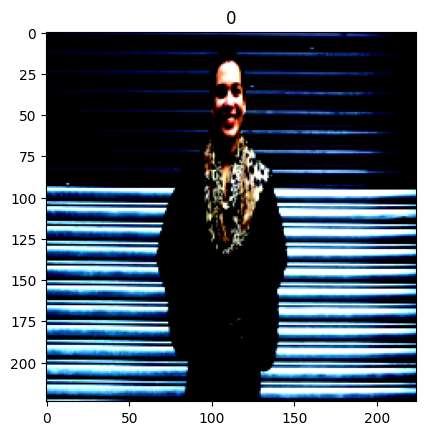

In [18]:
import matplotlib.pyplot as plt

img, label = dataset[0]

plt.imshow(img.permute(1,2,0))
plt.title(label)
plt.show()

In [ ]:
import time
import torch

EPOCHS = 10
best_acc = 0

for epoch in range(EPOCHS):

    start = time.time()

    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    loss = train_epoch()
    acc = validate()

    epoch_time = time.time() - start

    print(f"Loss: {loss:.4f}")
    print(f"Validation Accuracy: {acc:.4f}")
    print(f"Epoch Time: {epoch_time/60:.2f} minutes")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "../best_cnn_vit_model.pth")
        print("Best model saved")

    if (epoch + 1) % 2 == 0:
        torch.save(model.state_dict(), f"../checkpoint_epoch_{epoch+1}.pth")
        print(f"Checkpoint saved for epoch {epoch+1}")

print("\nTraining complete")
print(f"Best Validation Accuracy: {best_acc:.4f}")